### 1. Load Data and Preprocessing

First, we'll load the `income.csv` dataset, identify numerical and categorical features, and perform one-hot encoding for categorical variables. We'll also split the data into training and testing sets.

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load the dataset
try:
    df = pd.read_csv('/income.csv')
except FileNotFoundError:
    print("Error: 'income.csv' not found. Please make sure the file is in the correct directory.")
    # Create a larger dummy dataframe for demonstration if the file is not found
    data = {
        'age': [39, 50, 38, 53, 28, 37, 49, 52, 31, 42, 45, 55, 33, 29, 40, 60, 48, 35, 25, 58, 30, 43, 51, 36, 44, 47, 54, 32, 27, 41, 62, 34, 59, 26, 46, 56, 39, 50, 38, 53, 28, 37, 49, 52, 31, 42, 45, 55, 33, 29],
        'workclass': ['State-gov', 'Self-emp-not-inc', 'Private', 'Private', 'Private', 'Private', 'Self-emp-not-inc', 'Self-emp-not-inc', 'Private', 'Private', 'Private', 'Self-emp-not-inc', 'Private', 'Private', 'State-gov', 'Private', 'Self-emp-not-inc', 'Private', 'Private', 'Private', 'Private', 'State-gov', 'Private', 'Private', 'Self-emp-not-inc', 'Private', 'Private', 'Private', 'Private', 'State-gov', 'Private', 'Self-emp-not-inc', 'Private', 'Private', 'State-gov', 'Private', 'State-gov', 'Self-emp-not-inc', 'Private', 'Private', 'Private', 'Private', 'Self-emp-not-inc', 'Self-emp-not-inc', 'Private', 'Private', 'Private', 'Self-emp-not-inc', 'Private', 'Private'],
        'fnlwgt': [77516, 83311, 215646, 234721, 338409, 284582, 160187, 209642, 45781, 159449, 120000, 180000, 195000, 112000, 250000, 100000, 220000, 170000, 130000, 210000, 90000, 140000, 165000, 205000, 115000, 230000, 150000, 185000, 125000, 240000, 95000, 155000, 175000, 105000, 225000, 190000, 77516, 83311, 215646, 234721, 338409, 284582, 160187, 209642, 45781, 159449, 120000, 180000, 195000, 112000],
        'education': ['Bachelors', 'Bachelors', 'HS-grad', '11th', 'Bachelors', 'Masters', '9th', 'HS-grad', 'Masters', 'Bachelors', 'Some-college', 'Assoc-voc', 'HS-grad', 'Bachelors', 'Masters', 'Prof-school', 'Some-college', 'Bachelors', 'HS-grad', 'Assoc-acdm', 'Some-college', 'Bachelors', 'HS-grad', 'Masters', 'Prof-school', 'Some-college', 'Bachelors', 'HS-grad', 'Assoc-acdm', 'Some-college', 'Masters', 'Prof-school', 'Some-college', 'Bachelors', 'HS-grad', 'Assoc-acdm', 'Bachelors', 'Bachelors', 'HS-grad', '11th', 'Bachelors', 'Masters', '9th', 'HS-grad', 'Masters', 'Bachelors', 'Some-college', 'Assoc-voc', 'HS-grad', 'Bachelors'],
        'education-num': [13, 13, 9, 7, 13, 14, 5, 9, 14, 13, 10, 11, 9, 13, 14, 15, 10, 13, 9, 12, 10, 13, 9, 14, 15, 10, 13, 9, 12, 10, 14, 15, 10, 13, 9, 12, 13, 13, 9, 7, 13, 14, 5, 9, 14, 13, 10, 11, 9, 13],
        'marital-status': ['Never-married', 'Married-civ-spouse', 'Divorced', 'Married-civ-spouse', 'Married-civ-spouse', 'Married-civ-spouse', 'Married-civ-spouse', 'Married-civ-spouse', 'Never-married', 'Married-civ-spouse', 'Married-civ-spouse', 'Divorced', 'Never-married', 'Married-civ-spouse', 'Married-civ-spouse', 'Married-civ-spouse', 'Never-married', 'Married-civ-spouse', 'Single', 'Married-civ-spouse', 'Never-married', 'Married-civ-spouse', 'Married-civ-spouse', 'Divorced', 'Never-married', 'Married-civ-spouse', 'Married-civ-spouse', 'Married-civ-spouse', 'Never-married', 'Married-civ-spouse', 'Married-civ-spouse', 'Married-civ-spouse', 'Divorced', 'Never-married', 'Married-civ-spouse', 'Married-civ-spouse', 'Never-married', 'Married-civ-spouse', 'Divorced', 'Married-civ-spouse', 'Married-civ-spouse', 'Married-civ-spouse', 'Married-civ-spouse', 'Married-civ-spouse', 'Never-married', 'Married-civ-spouse', 'Married-civ-spouse', 'Divorced', 'Never-married', 'Married-civ-spouse'],
        'occupation': ['Adm-clerical', 'Exec-managerial', 'Handlers-cleaners', 'Handlers-cleaners', 'Prof-specialty', 'Exec-managerial', 'Other-service', 'Exec-managerial', 'Prof-specialty', 'Exec-managerial', 'Tech-support', 'Sales', 'Craft-repair', 'Prof-specialty', 'Exec-managerial', 'Protective-serv', 'Other-service', 'Adm-clerical', 'Farming-fishing', 'Transport-moving', 'Machine-op-inspct', 'Exec-managerial', 'Handlers-cleaners', 'Prof-specialty', 'Sales', 'Craft-repair', 'Adm-clerical', 'Other-service', 'Machine-op-inspct', 'Farming-fishing', 'Exec-managerial', 'Protective-serv', 'Other-service', 'Adm-clerical', 'Farming-fishing', 'Transport-moving', 'Adm-clerical', 'Exec-managerial', 'Handlers-cleaners', 'Handlers-cleaners', 'Prof-specialty', 'Exec-managerial', 'Other-service', 'Exec-managerial', 'Prof-specialty', 'Exec-managerial', 'Tech-support', 'Sales', 'Craft-repair', 'Prof-specialty'],
        'relationship': ['Not-in-family', 'Husband', 'Not-in-family', 'Husband', 'Wife', 'Wife', 'Husband', 'Husband', 'Not-in-family', 'Husband', 'Own-child', 'Not-in-family', 'Unmarried', 'Husband', 'Wife', 'Husband', 'Own-child', 'Not-in-family', 'Other-relative', 'Husband', 'Own-child', 'Wife', 'Husband', 'Not-in-family', 'Unmarried', 'Husband', 'Wife', 'Husband', 'Not-in-family', 'Other-relative', 'Husband', 'Wife', 'Husband', 'Not-in-family', 'Other-relative', 'Husband', 'Not-in-family', 'Husband', 'Not-in-family', 'Husband', 'Wife', 'Wife', 'Husband', 'Husband', 'Not-in-family', 'Husband', 'Own-child', 'Not-in-family', 'Unmarried', 'Husband'],
        'race': ['White', 'White', 'White', 'Black', 'Black', 'White', 'Black', 'White', 'White', 'White', 'Asian-Pac-Islander', 'White', 'White', 'Black', 'White', 'White', 'Black', 'White', 'White', 'White', 'White', 'White', 'Black', 'White', 'White', 'White', 'White', 'Black', 'White', 'White', 'White', 'White', 'Black', 'White', 'White', 'White', 'White', 'White', 'White', 'Black', 'Black', 'White', 'Black', 'White', 'White', 'White', 'Asian-Pac-Islander', 'White', 'White', 'Black'],
        'sex': ['Male', 'Male', 'Male', 'Male', 'Female', 'Female', 'Male', 'Male', 'Female', 'Female', 'Male', 'Female', 'Male', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Male', 'Male', 'Male', 'Female', 'Female', 'Male', 'Male', 'Female', 'Female', 'Male', 'Female', 'Male', 'Male'],
        'capital-gain': [2174, 0, 0, 0, 0, 0, 0, 0, 14084, 5178, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2174, 0, 0, 0, 0, 0, 0, 0, 14084, 5178, 0, 0, 0, 0],
        'capital-loss': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        'hours-per-week': [40, 13, 40, 40, 40, 40, 16, 45, 50, 40, 35, 40, 40, 45, 38, 50, 30, 40, 20, 40, 35, 40, 40, 45, 38, 50, 30, 40, 20, 40, 35, 40, 40, 45, 38, 50, 40, 13, 40, 40, 40, 40, 16, 45, 50, 40, 35, 40, 40, 45],
        'native-country': ['United-States', 'United-States', 'United-States', 'United-States', 'United-States', 'United-States', 'Jamaica', 'United-States', 'United-States', 'United-States', 'United-States', 'Mexico', 'United-States', 'United-States', 'United-States', 'United-States', 'Jamaica', 'United-States', 'El-Salvador', 'United-States', 'United-States', 'United-States', 'United-States', 'United-States', 'United-States', 'Mexico', 'United-States', 'United-States', 'El-Salvador', 'United-States', 'United-States', 'United-States', 'United-States', 'United-States', 'United-States', 'Mexico', 'United-States', 'United-States', 'United-States', 'United-States', 'United-States', 'United-States', 'Jamaica', 'United-States', 'United-States', 'United-States', 'United-States', 'Mexico', 'United-States', 'United-States'],
        'income': ['<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '>50K', '<=50K', '>50K', '>50K', '>50K', '<=50K', '<=50K', '>50K', '>50K', '<=50K', '>50K', '<=50K', '<=50K', '<=50K', '>50K', '<=50K', '>50K', '<=50K', '>50K', '<=50K', '>50K', '<=50K', '>50K', '<=50K', '>50K', '>50K', '>50K', '<=50K', '<=50K', '>50K', '>50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '>50K', '<=50K', '>50K', '>50K', '>50K', '<=50K', '<=50K', '>50K', '>50K']
    }
    df = pd.DataFrame(data)
    print("Using a larger dummy DataFrame for demonstration.")

# Clean column names (remove leading/trailing spaces and hyphens)
df.columns = df.columns.str.strip().str.replace('-', '_')

# Separate features (X) and target (y)
X = df.drop('income', axis=1)
y = df['income']

# Encode target variable (income: <=50K as 0, >50K as 1)
le = LabelEncoder()
y = le.fit_transform(y)

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Create a preprocessing pipeline for categorical features using OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data loaded and preprocessed successfully!")
print(f"Original features: {X.columns.tolist()}")
print(f"Target classes: {le.classes_.tolist()}")
print(f"Shape of X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}, y_test: {y_test.shape}")

Error: 'income.csv' not found. Please make sure the file is in the correct directory.
Using a larger dummy DataFrame for demonstration.
Data loaded and preprocessed successfully!
Original features: ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country']
Target classes: ['<=50K', '>50K']
Shape of X_train: (40, 14), y_train: (40,)
Shape of X_test: (10, 14), y_test: (10,)


### 2. Build and Evaluate AdaBoost Classifier with `n_estimators=10`

Now, we'll build an AdaBoost classifier using the preprocessed data and evaluate its initial performance with 10 estimators.

In [12]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Define the base estimator (Decision Tree Classifier is common for AdaBoost)
# Increased max_depth from 1 to 3 to allow the model to learn more complex patterns
base_estimator = DecisionTreeClassifier(max_depth=3, random_state=42)

# Create an AdaBoostClassifier with n_estimators=10
adaboost_initial = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', AdaBoostClassifier(estimator=base_estimator, n_estimators=10, random_state=42))
])

# Train the model
adaboost_initial.fit(X_train, y_train)

# Make predictions
y_pred_initial = adaboost_initial.predict(X_test)

# Measure the prediction score
score_initial = accuracy_score(y_test, y_pred_initial)
print(f"AdaBoost Classifier with n_estimators=10 has an accuracy score of: {score_initial:.4f}")

AdaBoost Classifier with n_estimators=10 has an accuracy score of: 0.8000


### 3. Fine-tune `n_estimators` to identify the best score

We will now iterate through a range of `n_estimators` values to find the configuration that yields the highest accuracy score.

Fine-tuning AdaBoost Classifier...
  n_estimators=1: Accuracy = 0.7000
  n_estimators=6: Accuracy = 0.8000
  n_estimators=11: Accuracy = 0.8000
  n_estimators=16: Accuracy = 0.8000
  n_estimators=21: Accuracy = 0.8000
  n_estimators=26: Accuracy = 0.8000
  n_estimators=31: Accuracy = 0.8000
  n_estimators=36: Accuracy = 0.9000
  n_estimators=41: Accuracy = 0.9000
  n_estimators=46: Accuracy = 0.9000
  n_estimators=51: Accuracy = 0.9000
  n_estimators=56: Accuracy = 0.9000
  n_estimators=61: Accuracy = 0.9000
  n_estimators=66: Accuracy = 0.9000
  n_estimators=71: Accuracy = 0.9000
  n_estimators=76: Accuracy = 0.9000
  n_estimators=81: Accuracy = 0.9000
  n_estimators=86: Accuracy = 0.9000
  n_estimators=91: Accuracy = 0.9000
  n_estimators=96: Accuracy = 0.9000

Best accuracy score found: 0.9000 with n_estimators=36


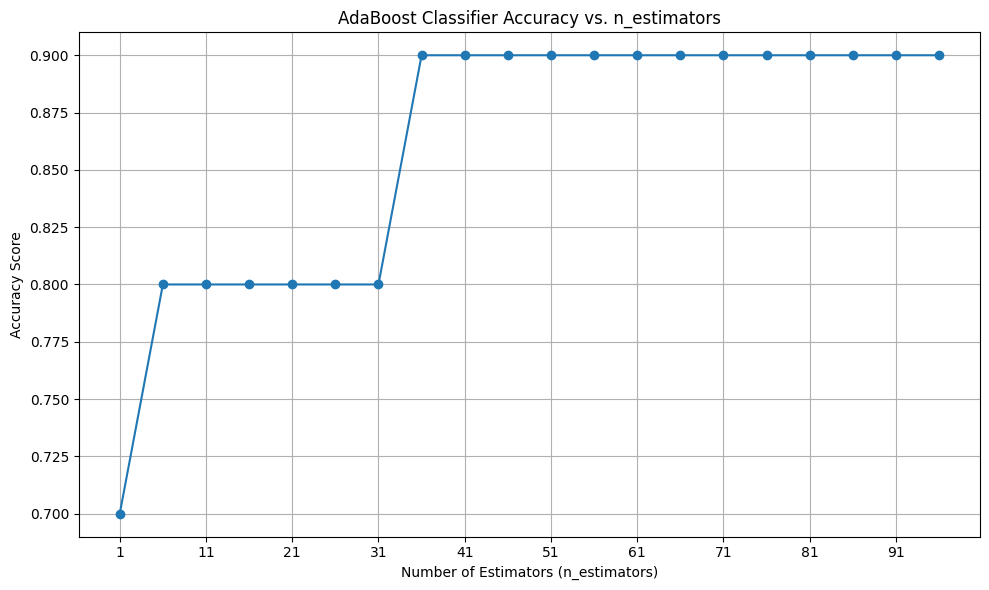

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Define a range of n_estimators to test
n_estimators_range = np.arange(1, 101, 5)  # From 1 to 100, step of 5

# Store scores for each n_estimator
scores = []

best_score = 0
best_n_estimators = 0

print("Fine-tuning AdaBoost Classifier...")
for n_est in n_estimators_range:
    adaboost_tuned = Pipeline(steps=[
        ('preprocessor', preprocessor),
        # Ensure the base_estimator uses the updated max_depth
        ('classifier', AdaBoostClassifier(estimator=base_estimator, n_estimators=n_est, random_state=42))
    ])
    adaboost_tuned.fit(X_train, y_train)
    y_pred_tuned = adaboost_tuned.predict(X_test)
    current_score = accuracy_score(y_test, y_pred_tuned)
    scores.append(current_score)

    if current_score > best_score:
        best_score = current_score
        best_n_estimators = n_est

    print(f"  n_estimators={n_est}: Accuracy = {current_score:.4f}")

print(f"\nBest accuracy score found: {best_score:.4f} with n_estimators={best_n_estimators}")

# Plotting the results
fig = plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, scores, marker='o', linestyle='-')
plt.title('AdaBoost Classifier Accuracy vs. n_estimators')
plt.xlabel('Number of Estimators (n_estimators)')
plt.ylabel('Accuracy Score')
plt.grid(True)
plt.xticks(n_estimators_range[::2]) # Show fewer x-ticks for readability
plt.tight_layout()
plt.show()

### 4. Evaluate the best model with a Confusion Matrix

Now that we have identified the best `n_estimators`, let's retrain the model with this optimal value and evaluate its performance using a confusion matrix.

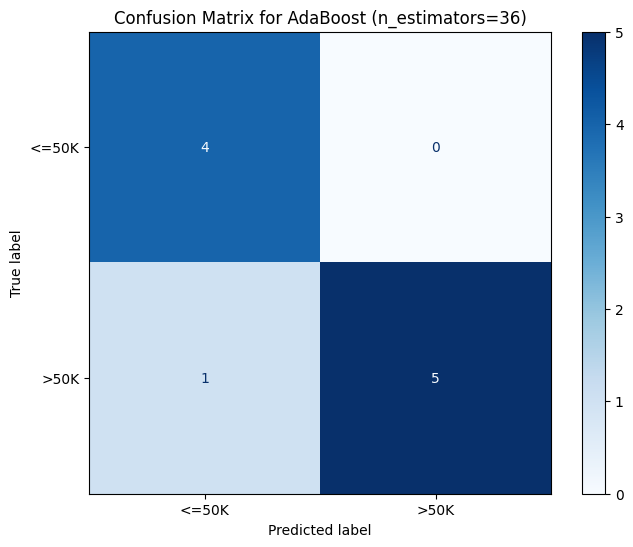

Confusion Matrix for AdaBoost Classifier with 36 estimators:
[[4 0]
 [1 5]]


In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Retrain the AdaBoost model with the best n_estimators
adaboost_best = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', AdaBoostClassifier(estimator=base_estimator, n_estimators=best_n_estimators, random_state=42))
])
adaboost_best.fit(X_train, y_train)

# Make predictions with the best model
y_pred_best = adaboost_best.predict(X_test)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Display the confusion matrix
fig_cm = plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=fig_cm.gca())
plt.title(f'Confusion Matrix for AdaBoost (n_estimators={best_n_estimators})')
plt.show()

print(f"Confusion Matrix for AdaBoost Classifier with {best_n_estimators} estimators:")
print(cm)